## Ejemplo Decision Tree MNIST
<div style="border-style:groove;border-width:thin;padding:10px">
MNIST es un dataset de 70000 dígitos numéricos escritos a mano por empleados del censo y por estudiantes de instituto de EEUU. Para poder trabajar con él, las imágenes están digitalizadas y reducidas a 28x28 pixels en blanco y negro. El objetivo de esta actividad es entrenar un modelo de clasificación que consiga determinar de que número se trata en función de los 784 datos de entrada (28x28). Cada pixel se trata como una entrada al sistema. La salida será el número del 0 al 9 que identifica. 
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
A continuación vamos a importar el dataset y a generar los conjuntos X e y.
    </div>

In [15]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [16]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


<div style="border-style:groove;border-width:thin;padding:10px">
Ahora vamos a coger una muestra cualquiera y a pintarlo. Los datos están como un array de una dimensión y 784 valores. Hay que cambiarlos a un array de dos dimensiones de 28x28 para poder pintarlo como una imagen. 
    </div>

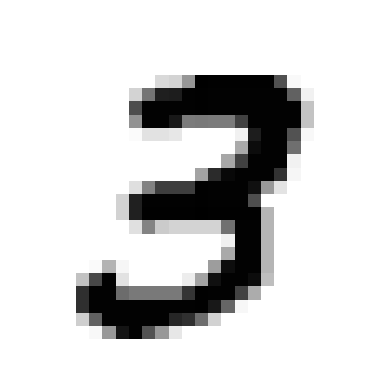

3


In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt


some_digit = X.iloc[[7]].values
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

print(y[7])

<div style="border-style:groove;border-width:thin;padding:10px">
Es tu turno! Trata de resolver el problema con un árbol de decisión siguiendo los pasos que se indican a continuación:
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
1. Divide el dataset en el conjunto de entrenamiento y de test.
    </div>

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((52500, 784), (17500, 784))

<div style="border-style:groove;border-width:thin;padding:10px">
2. Crea un árbol de decisión con los parámetros que quieras e intenta mostrar el gráfico del árbol.
    </div>

In [19]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [20]:
import os

from sklearn.tree import export_graphviz
export_graphviz(
    tree_clf,
    out_file="./iris_tree.dot",
    feature_names=mnist.feature_names[2:],
    class_names=mnist.target_names,
    rounded=True,
    filled=True
)

#Usa este comando para transformar la imagen en png y poder verla con el visor de imágenes del SO:
#sudo apt install graphviz
!dot -Tpng iris_tree.dot -o iris_tree.png

ValueError: Length of feature_names, 782 does not match number of features, 784

<div style="border-style:groove;border-width:thin;padding:10px">
3. Genera la predicción (y_pred) con el árbol entrenado y mira la precisión que has conseguido. Módifica los hiperparámetros del árbol en el código del punto 2 para mejorar los resultados.
    </div>

In [21]:
y_pred = tree_clf.predict(X_test)

<div style="border-style:groove;border-width:thin;padding:10px">
4. Recorre la muestra de test viendo los datos que son erróneos y muestra la imagen. Evalúa si el resultado es suficientemente bueno.
</div>

In [22]:
print(y_pred)

['4' '1' '4' ... '2' '4' '7']


In [23]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8731428571428571

Total de errores: 2220
Precisión: 87.31%


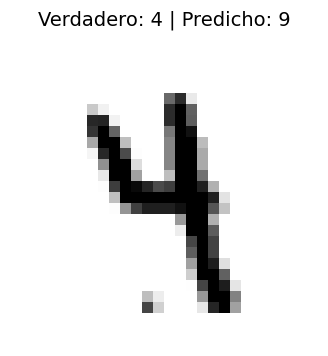

Error 1/2220
Valor real: 4
Predicción: 9
----------------------------------------


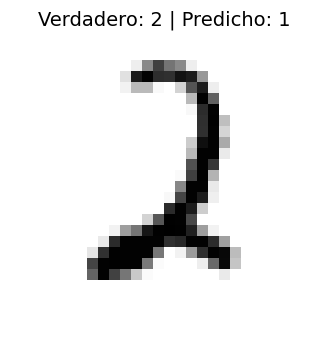

Error 2/2220
Valor real: 2
Predicción: 1
----------------------------------------


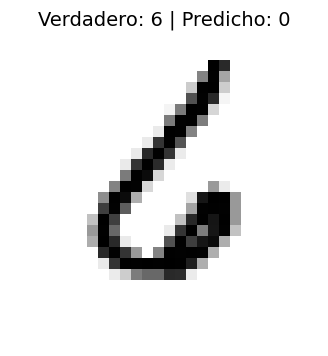

Error 3/2220
Valor real: 6
Predicción: 0
----------------------------------------


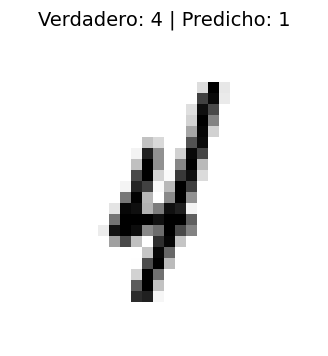

Error 4/2220
Valor real: 4
Predicción: 1
----------------------------------------


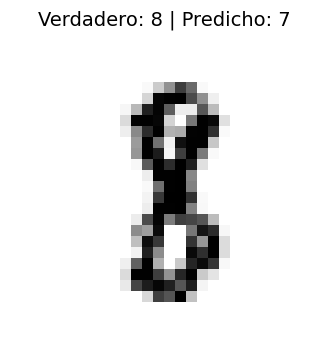

Error 5/2220
Valor real: 8
Predicción: 7
----------------------------------------


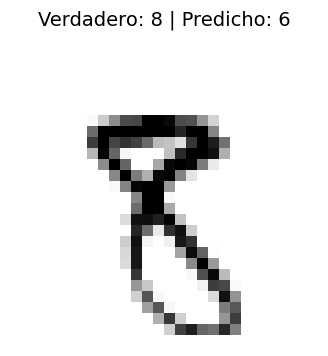

Error 6/2220
Valor real: 8
Predicción: 6
----------------------------------------

Mostrando solo los primeros 10 errores de 2220 totales


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Primero, obtener las predicciones
y_pred = tree_clf.predict(X_test)

# Encontrar los índices donde las predicciones son incorrectas
errores = y_test != y_pred
indices_errores = np.where(errores)[0]

print(f"Total de errores: {len(indices_errores)}")
print(f"Precisión: {(len(y_test) - len(indices_errores)) / len(y_test) * 100:.2f}%")

# Recorrer los errores y mostrar las imágenes
for i, idx in enumerate(indices_errores):
    # Obtener la imagen
    imagen = X_test.iloc[idx].values.reshape(28, 28)
    
    # Crear la figura
    plt.figure(figsize=(6, 4))
    plt.imshow(imagen, cmap="binary")
    plt.axis("off")
    
    # Agregar información sobre la predicción
    plt.title(f"Verdadero: {y_test.iloc[idx]} | Predicho: {y_pred[idx]}", 
              fontsize=14, pad=10)
    
    plt.show()
    
    print(f"Error {i+1}/{len(indices_errores)}")
    print(f"Valor real: {y_test.iloc[idx]}")
    print(f"Predicción: {y_pred[idx]}")
    print("-" * 40)
    
    if i >= 5:  # Mostrar solo los primeros 10 errores
        print(f"\nMostrando solo los primeros 10 errores de {len(indices_errores)} totales")
        break

<div style="border-style:groove;border-width:thin;padding:10px">
5. Prueba ahora a resolver el problema con SVM. 
    </div>

In [25]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
print("Entrenando SVM...")
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_clf.fit(X_train_scaled, y_train)


Entrenando SVM...


SVC(random_state=42)

In [27]:
y_pred = svm_clf.predict(X_test)
print(y_pred)

/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


['7' '7' '7' ... '7' '7' '7']


In [28]:
cr = classification_report(y_test, y_pred)
print(cr) 

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1726
           1       0.00      0.00      0.00      1969
           2       0.00      0.00      0.00      1748
           3       0.00      0.00      0.00      1785
           4       0.00      0.00      0.00      1706
           5       0.00      0.00      0.00      1578
           6       0.00      0.00      0.00      1719
           7       0.10      1.00      0.19      1823
           8       0.00      0.00      0.00      1706
           9       0.00      0.00      0.00      1740

    accuracy                           0.10     17500
   macro avg       0.01      0.10      0.02     17500
weighted avg       0.01      0.10      0.02     17500



/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.10417142857142857